In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path


cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from paper.style_utils import set_paper_style
set_paper_style()

import matplotlib.pyplot as plt

# Set global Seaborn style
%config InlineBackend.figure_format = 'retina'


In [3]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from common.consts import res_colors
from common.utils import collect_df, mfpt_table_from_samples
from common.hlda_utils import load_lambda_grid
from common.plot_utils import scatter_with_labels, add_linear_fit

data_dir = repo_root / "data"
mfpt_default_pkl = data_dir / "mfpt-pace=25000-new-ref.pkl"
tm_csv = data_dir / "Tm.csv"
lambda_cache = data_dir / "hlda_lambda_grid.pkl"


with open(mfpt_default_pkl, "rb") as f:
    mfpt_all = pickle.load(f)

mfpt_thresholds = sorted({float(k) for v in mfpt_all.values() for k in v.keys()})



tm = pd.read_csv(tm_csv, index_col="Mutant")
tm["Tm"] = pd.to_numeric(tm["Tm"], errors="coerce")
tm["abs_dTm"] = abs(tm["Tm"] - tm.loc["WT", "Tm"])

lambda_grid = load_lambda_grid(cache_path=lambda_cache, base_dir=data_dir / "hlda_trajectories", force=False)
lambda_grid.head()


,Mutant,tF,tU,lambda,nF,nU,var_F_diag,var_U_diag,weights,res_weights
0,D2A,0.18,0.30,6544.396562,8861,91951,"[0.0008478472743267516, 0.0011329781051374278,...","[0.021822002644914233, 0.034387766655950155, 0...","{'d03': 69.03, 'd04': -203.82, 'd05': 244.86, ...","[656.43, 466.42, 480.73, 216.16, 670.73, 519.5..."
1,D2A,0.18,0.35,6628.341806,8861,91356,"[0.0008478472743267516, 0.0011329781051374278,...","[0.021914678202689043, 0.034590364267731204, 0...","{'d03': 69.14, 'd04': -203.82, 'd05': 244.76, ...","[656.43, 466.47, 480.8, 216.07, 670.88, 519.33..."
2,D2A,0.18,0.41,7049.056425,8861,88358,"[0.0008478472743267516, 0.0011329781051374278,...","[0.022499551728532702, 0.03570512795072451, 0....","{'d03': 71.37, 'd04': -203.64, 'd05': 242.67, ...","[654.7, 465.52, 480.32, 217.01, 671.25, 515.24..."
3,D2A,0.18,0.46,7366.079490,8861,86336,"[0.0008478472743267516, 0.0011329781051374278,...","[0.022895281380262797, 0.03646222800497214, 0....","{'d03': 71.9, 'd04': -199.12, 'd05': 248.8, 'd...","[687.62, 467.04, 491.23, 216.11, 680.94, 525.8..."
4,D2A,0.18,0.52,7544.218118,8861,84109,"[0.0008478472743267516, 0.0011329781051374278,...","[0.023076225309800618, 0.036911968254067555, 0...","{'d03': 72.42, 'd04': -199.24, 'd05': 248.21, ...","[686.29, 467.89, 492.01, 216.01, 682.09, 524.8..."


In [4]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap="rocket_r"):
    P = df.pivot(index="tF", columns="tU", values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading="flat"
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f"{val:.2f}", ha="center", va="center", fontsize=6)

    ax.set_xlabel("Unfolded RMSD threshold (tU)")
    ax.set_ylabel("Folded RMSD threshold (tF)")
    return im


def add_wt_point(ax, lambda_df, tF, tU):
    wt_rows = lambda_df[(lambda_df["Mutant"] == "WT") & np.isclose(lambda_df["tF"], tF) & np.isclose(lambda_df["tU"], tU)]
    if wt_rows.empty:
        return
    x_wt = float(wt_rows["lambda"].iloc[0])
    ax.scatter([x_wt], [0.0], s=90, marker="*", color="red", edgecolor="black", zorder=5)
    y_min, y_max = ax.get_ylim()
    dy = 0.02 * (y_max - y_min if y_max > y_min else 1.0)
    ax.text(x_wt, dy, "WT", ha="center", va="bottom", fontsize=8, color="red", weight="bold")


def scatter_with_labels_ax(ax, df, x_col, y_col, label_col, title, xlab, ylab, rho, tF, tU, add_wt=True, corr_label="|ρ|"):
    if not df.empty:
        scatter_with_labels(
            ax,
            df,
            x_col,
            y_col,
            label_col=label_col,
            color_col="residue_idx",
            colors=res_colors,
            s=40,
            edgecolor="k",
            linewidth=0.6,
            alpha=0.85,
            annotate=True,
        )

    if add_wt:
        add_wt_point(ax, lambda_grid, tF, tU)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)


def mfpt_table_to_log_ratio(df_raw):
    if "Mutant" not in df_raw.columns:
        df = df_raw.rename_axis("Mutant").reset_index()
    else:
        df = df_raw.copy()
    df["Mutant"] = df["Mutant"].astype(str).str.strip()
    df["MFPT"] = df["mfpt"] / 1e6
    mfpt_wt = df.loc[df["Mutant"] == "WT", "MFPT"].iloc[0]
    df["log_mfpt_ratio"] = np.log(mfpt_wt / df["MFPT"])
    return df[["Mutant", "log_mfpt_ratio"]]


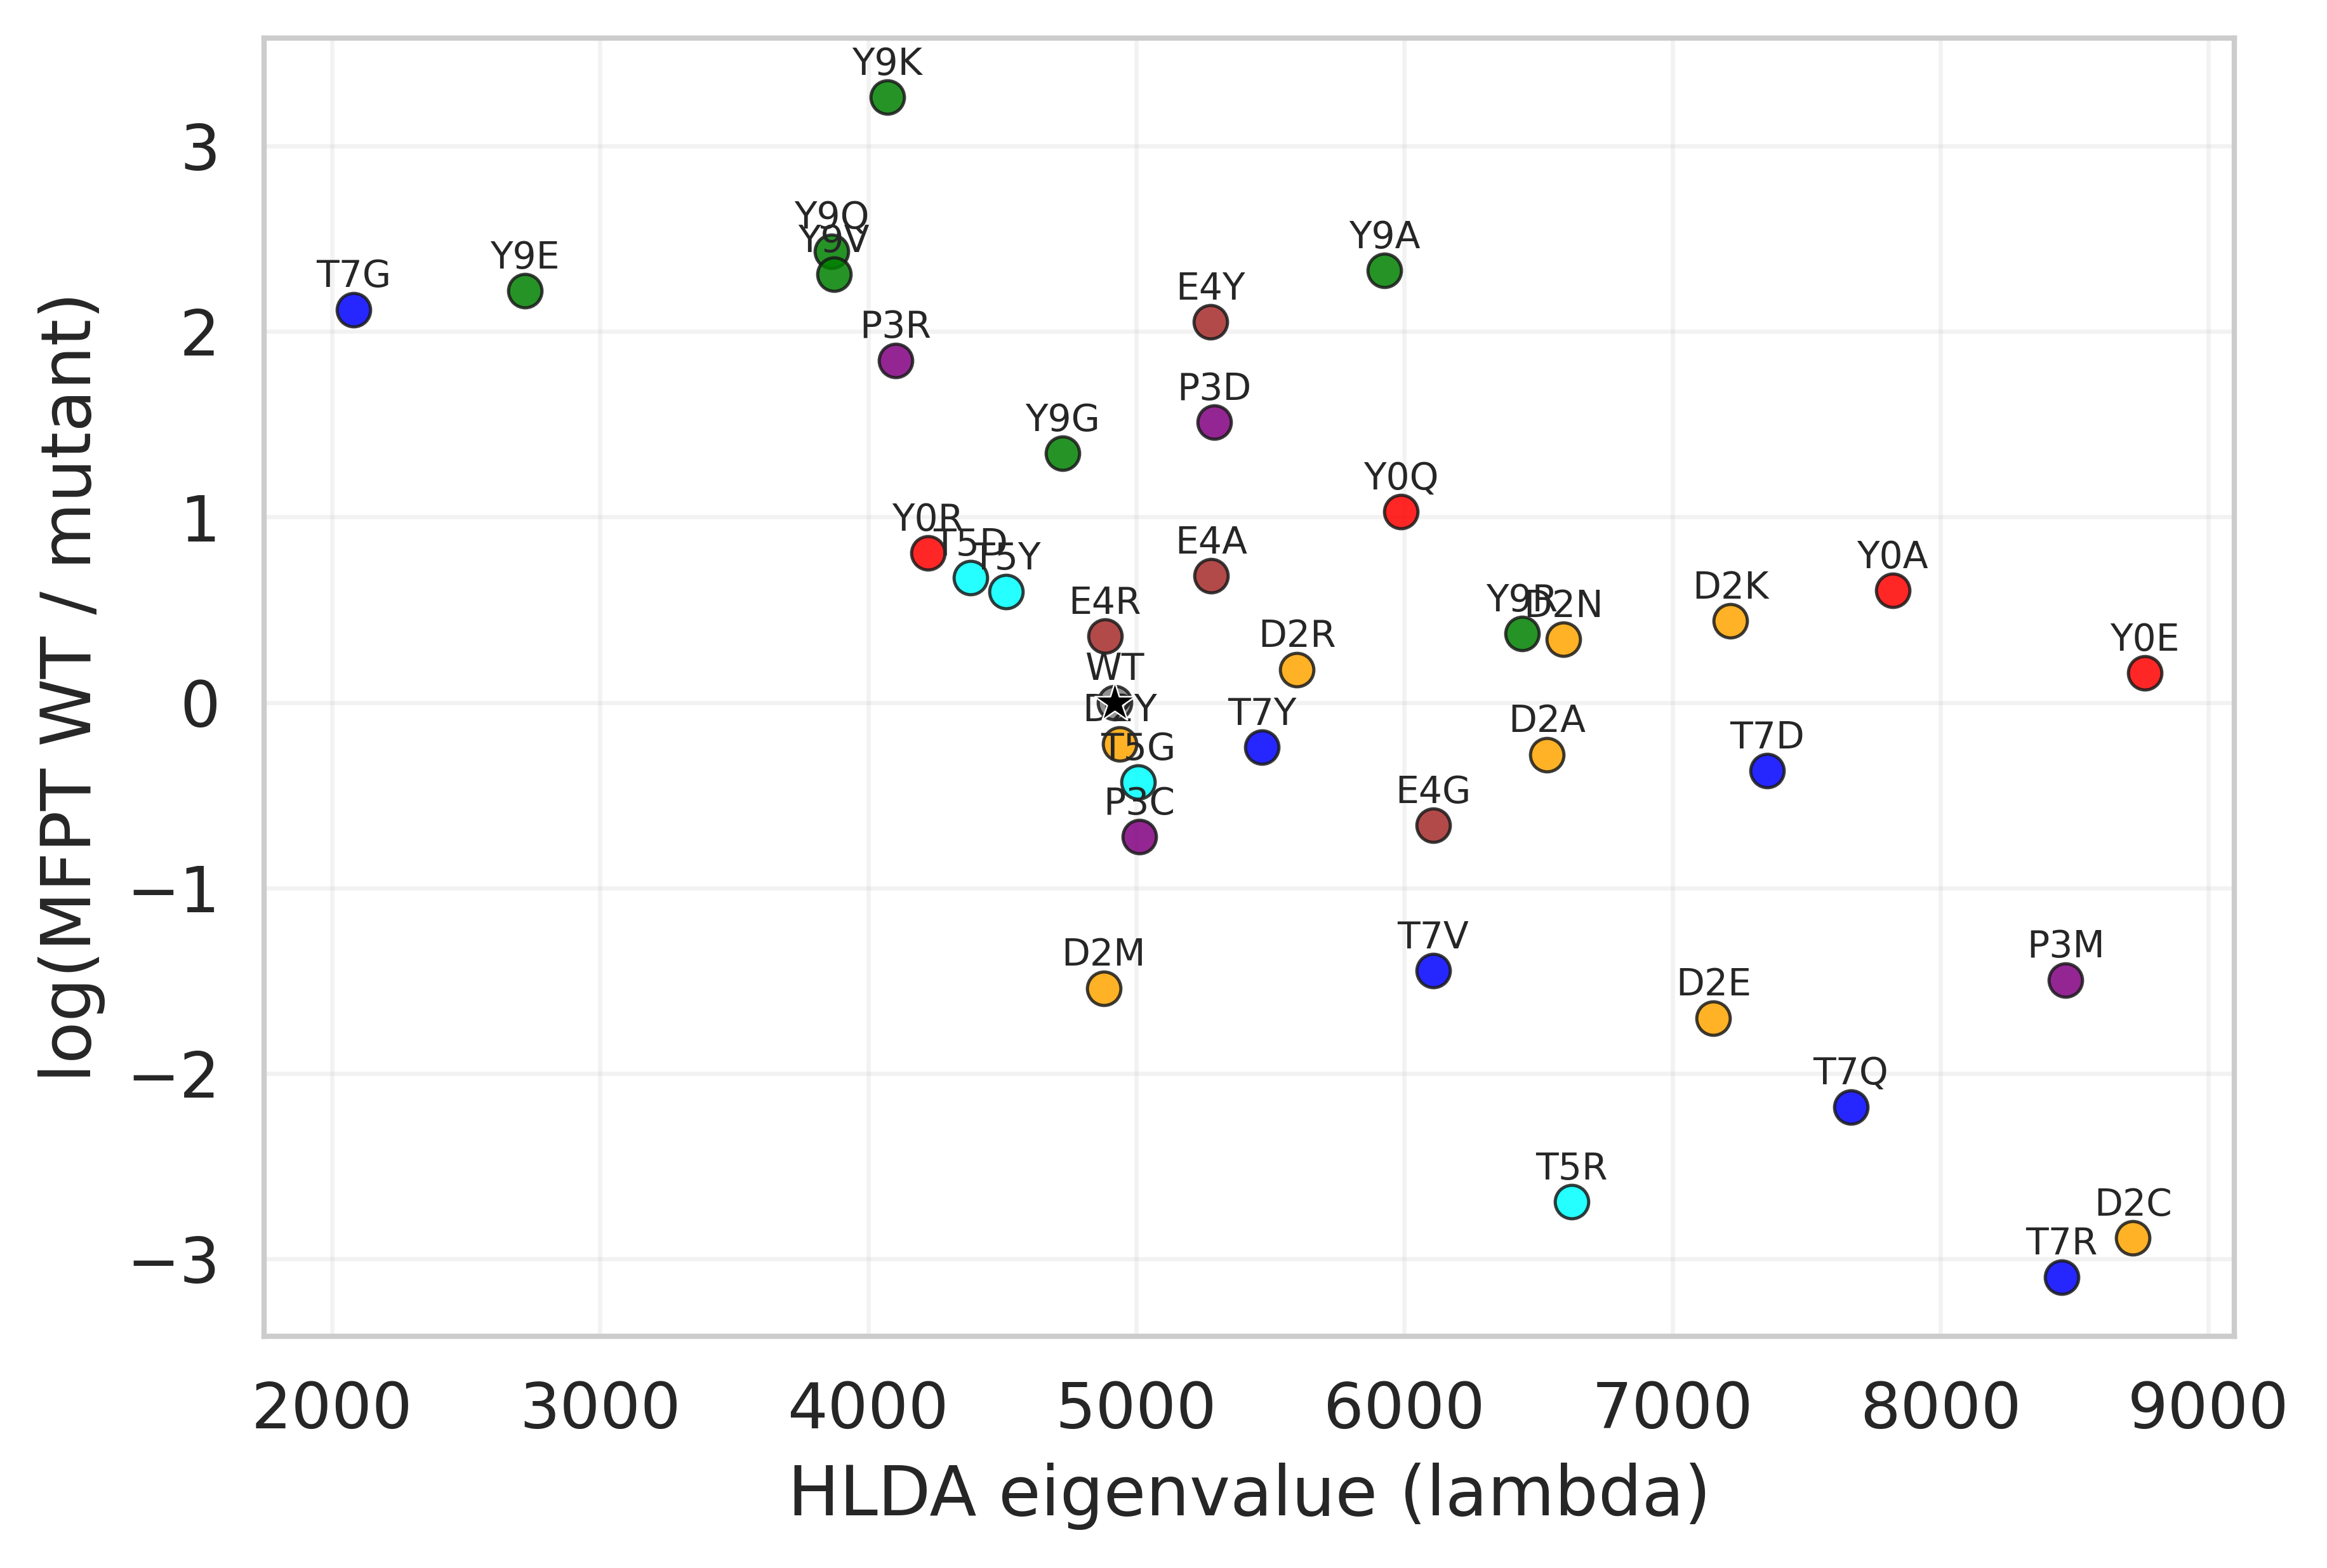

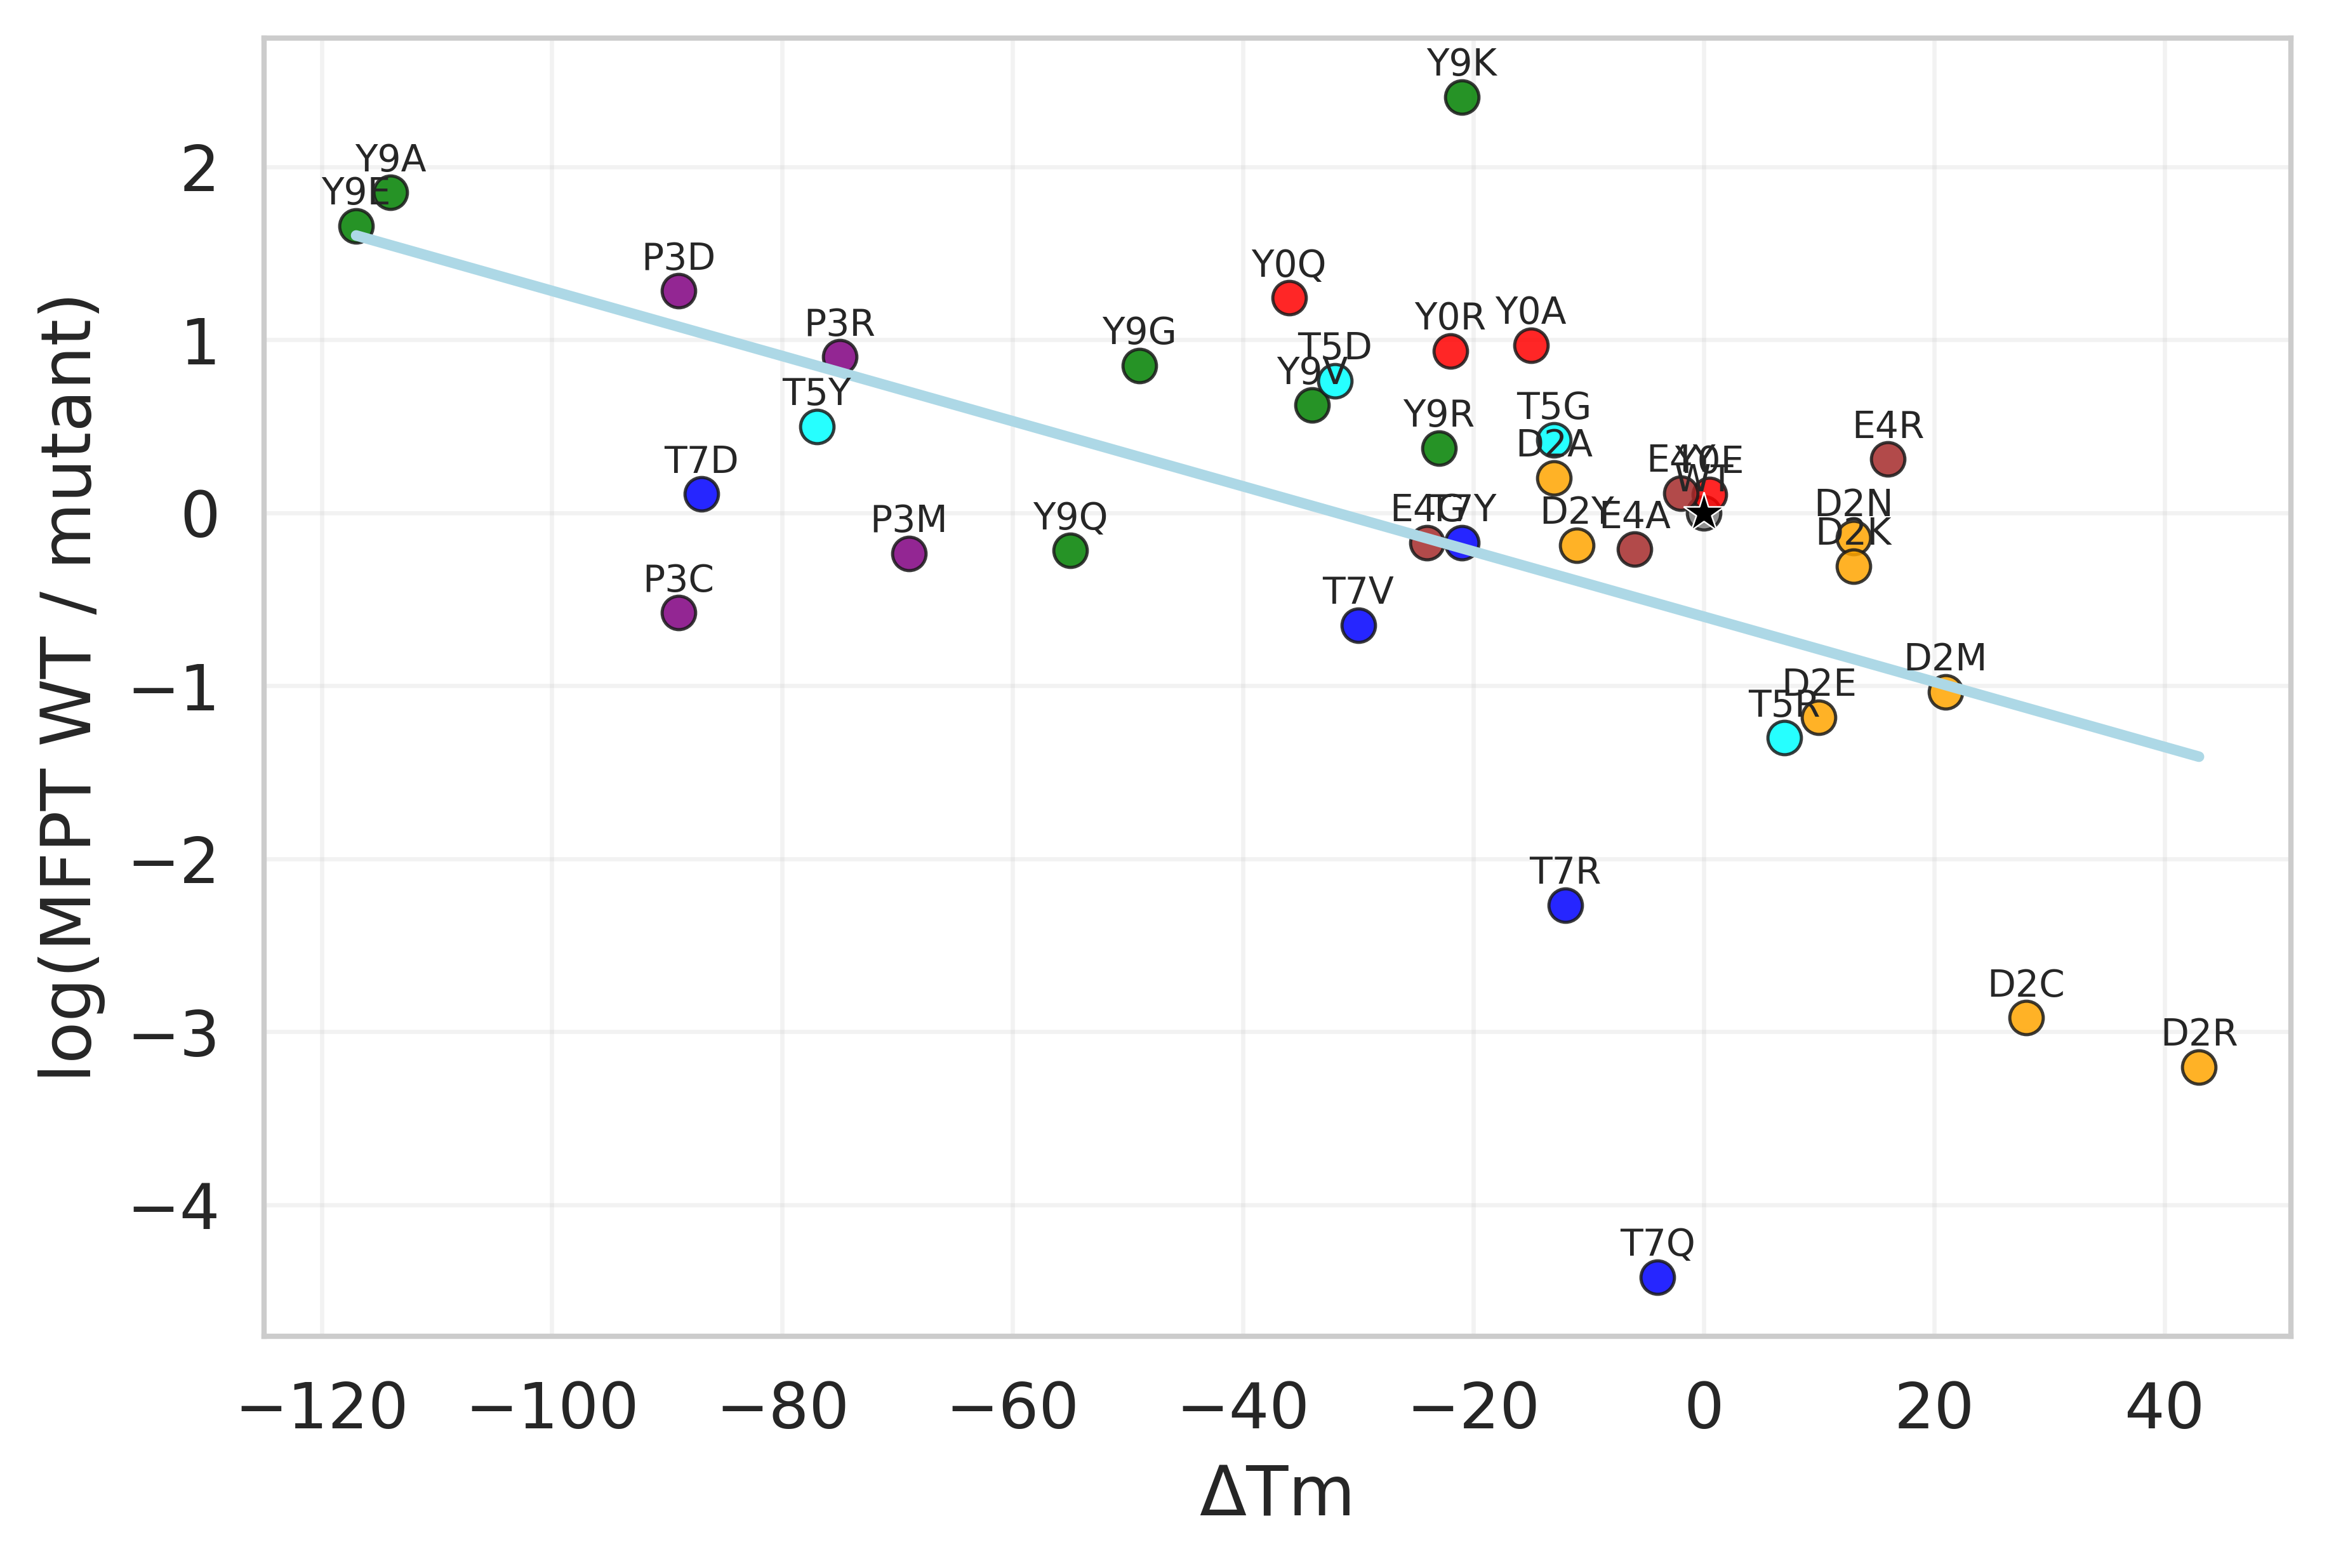

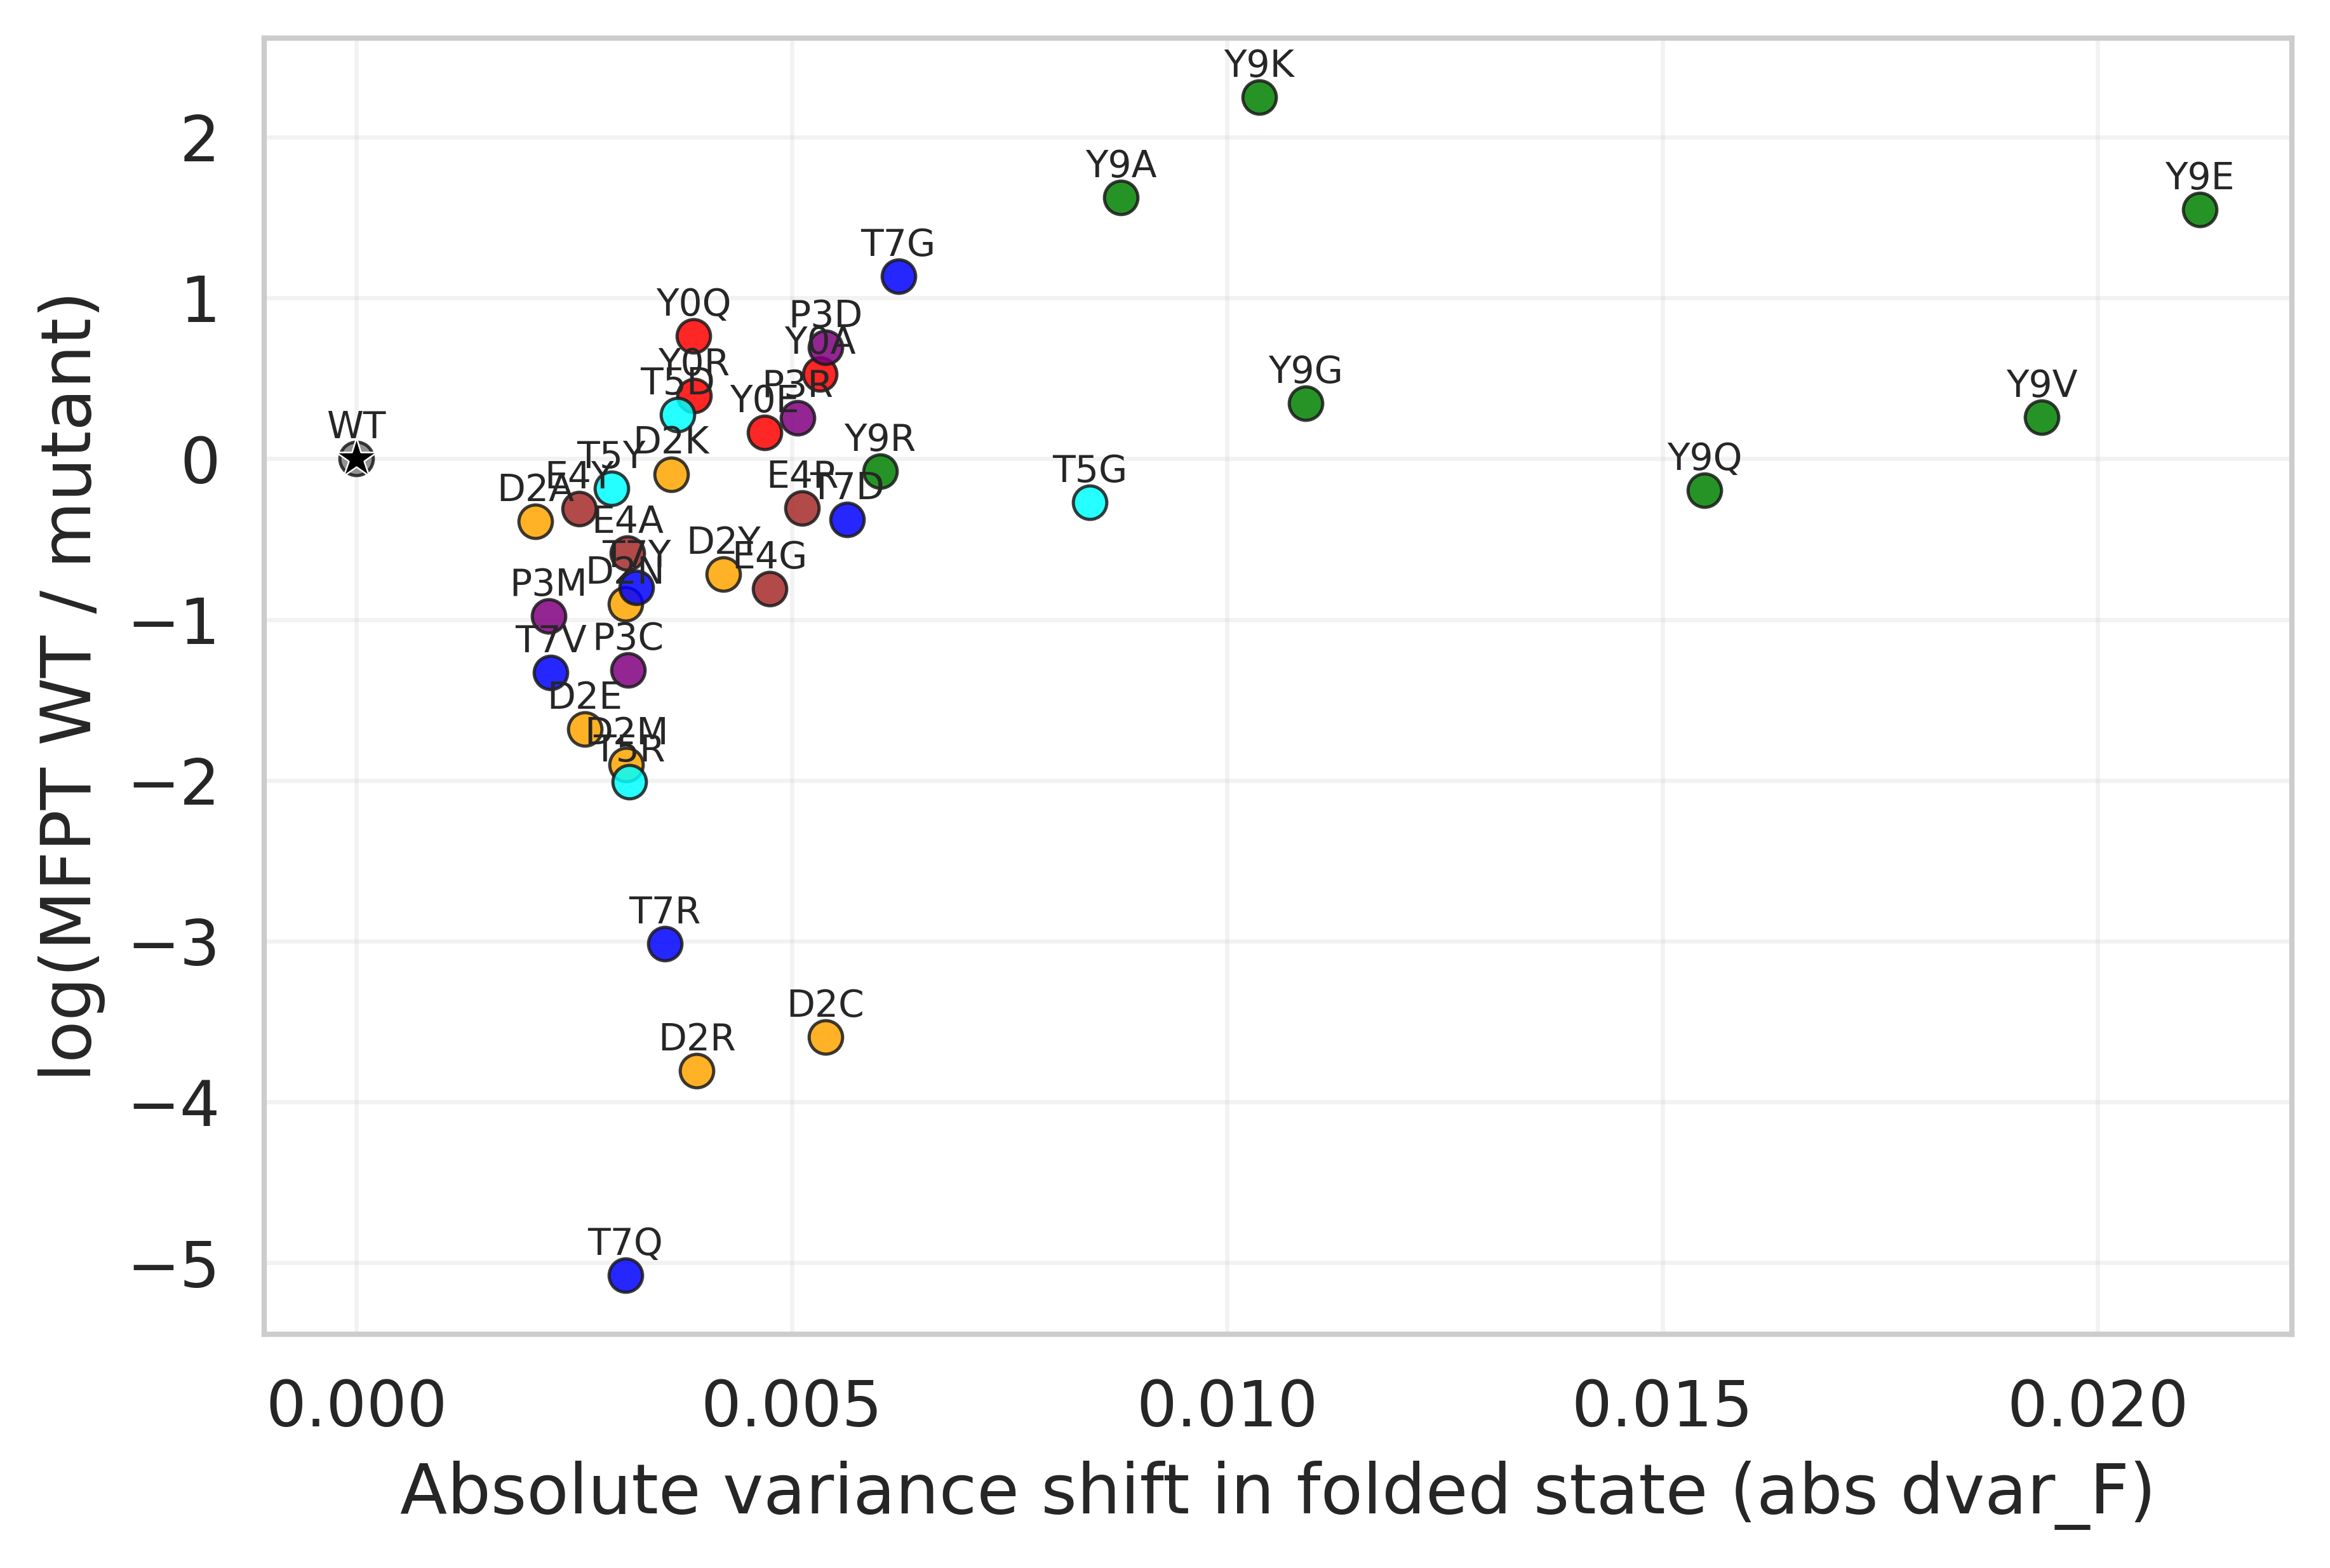

In [7]:
# Correlations using best thresholds (separate plots)
feature_df_map = {
    'dTm': None,
    'abs_dvar_F': None,
}

# dTm best
best_dtm = None
pairs = lambda_grid[['tF', 'tU']].drop_duplicates().to_numpy()
for thr in mfpt_thresholds:
    for tF, tU in pairs:
        sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
        df_thr = collect_df(
            mfpt_all,
            mfpt_threshold=float(thr),
            tF=float(tF),
            tU=float(tU),
            lambda_df=sub_lam,
            skip_short={},
            quiet=True,
        )
        wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
        df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])
        sub = df_thr.dropna(subset=['dTm', 'log_mfpt_ratio'])
        rho = sub['dTm'].corr(sub['log_mfpt_ratio'], method='spearman')
        val = abs(rho) if pd.notna(rho) else np.nan
        if best_dtm is None or val > best_dtm['rho_abs']:
            best_dtm = {
                'thr': float(thr),
                'tF': float(tF),
                'tU': float(tU),
                'rho_abs': float(val),
            }


# abs_dvar_F best
best_abs_dvar = None
pairs = lambda_grid[['tF', 'tU']].drop_duplicates().to_numpy()
for thr in mfpt_thresholds:
    for tF, tU in pairs:
        sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
        df_thr = collect_df(
            mfpt_all,
            mfpt_threshold=float(thr),
            tF=float(tF),
            tU=float(tU),
            lambda_df=sub_lam,
            skip_short={},
            quiet=True,
        )
        wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
        df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])
        sub = df_thr.dropna(subset=['abs_dvar_F', 'log_mfpt_ratio'])
        rho = sub['abs_dvar_F'].corr(sub['log_mfpt_ratio'], method='spearman')
        val = abs(rho) if pd.notna(rho) else np.nan
        if best_abs_dvar is None or val > best_abs_dvar['rho_abs']:
            best_abs_dvar = {
                'thr': float(thr),
                'tF': float(tF),
                'tU': float(tU),
                'rho_abs': float(val),
            }

_tF = float(best_dtm['tF'])
_tU = float(best_dtm['tU'])
_thr = float(best_dtm['thr'])
_sub_lam = lambda_grid[(lambda_grid['tF'] == _tF) & (lambda_grid['tU'] == _tU)]
_df = collect_df(
    mfpt_all,
    mfpt_threshold=_thr,
    tF=_tF,
    tU=_tU,
    lambda_df=_sub_lam,
    skip_short={},
    quiet=True,
)
_wt_mfpt = float(_df.loc['WT', 'mfpt'])
_df['log_mfpt_ratio'] = np.log(_wt_mfpt / _df['mfpt'])
feature_df_map['dTm'] = _df


_tF_dv = float(best_abs_dvar['tF'])
_tU_dv = float(best_abs_dvar['tU'])
_thr_dv = float(best_abs_dvar['thr'])
_sub_lam_dv = lambda_grid[(lambda_grid['tF'] == _tF_dv) & (lambda_grid['tU'] == _tU_dv)]
_df_dv = collect_df(
    mfpt_all,
    mfpt_threshold=_thr_dv,
    tF=_tF_dv,
    tU=_tU_dv,
    lambda_df=_sub_lam_dv,
    skip_short={},
    quiet=True,
)
_wt_mfpt_dv = float(_df_dv.loc['WT', 'mfpt'])
_df_dv['log_mfpt_ratio'] = np.log(_wt_mfpt_dv / _df_dv['mfpt'])
feature_df_map['abs_dvar_F'] = _df_dv

# Lambda (MFPT-best) plot
sub = summary_df.dropna(subset=['lambda', 'log_mfpt_ratio']).copy()
fig, ax = plt.subplots(figsize=(6.2, 4.2))
palette = {int(k): v for k, v in res_colors.items() if k in sub['residue_idx'].unique()}
scatter_with_labels(
    ax,
    sub,
    'lambda',
    'log_mfpt_ratio',
    label_col=None,
    color_col='residue_idx',
    colors=palette,
    s=40,
    edgecolor='k',
    linewidth=0.6,
    alpha=0.85,
    annotate=True,
)
wt_row = sub.loc[sub.index == 'WT']
wt_x = float(wt_row.iloc[0]['lambda'])
wt_y = float(wt_row.iloc[0]['log_mfpt_ratio'])
ax.plot(
    wt_x,
    wt_y,
    marker='*',
    markersize=8,
    color='black',
    markeredgecolor='white',
    markeredgewidth=0.3,
    zorder=5,
)
rho = sub['lambda'].corr(sub['log_mfpt_ratio'], method='spearman')
ax.set_xlabel('HLDA eigenvalue (lambda)')
ax.set_ylabel('log(MFPT WT / mutant)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()



# dTm plot
sub = feature_df_map['dTm'].dropna(subset=['dTm', 'log_mfpt_ratio']).copy()
fig, ax = plt.subplots(figsize=(6.2, 4.2))
palette = {int(k): v for k, v in res_colors.items() if k in sub['residue_idx'].unique()}
scatter_with_labels(
    ax,
    sub,
    'dTm',
    'log_mfpt_ratio',
    label_col=None,
    color_col='residue_idx',
    colors=palette,
    s=40,
    edgecolor='k',
    linewidth=0.6,
    alpha=0.85,
    annotate=True,
)
wt_row = sub.loc[sub.index == 'WT']
wt_x = float(wt_row.iloc[0]['dTm'])
wt_y = float(wt_row.iloc[0]['log_mfpt_ratio'])
add_linear_fit(ax, sub['dTm'], sub['log_mfpt_ratio'])
ax.plot(
    wt_x,
    wt_y,
    marker='*',
    markersize=8,
    color='black',
    markeredgecolor='white',
    markeredgewidth=0.3,
    zorder=5,
)
rho = sub['dTm'].corr(sub['log_mfpt_ratio'], method='spearman')
ax.set_xlabel('ΔTm')
ax.set_ylabel('log(MFPT WT / mutant)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


# abs_dvar_F plot
sub = feature_df_map['abs_dvar_F'].dropna(subset=['abs_dvar_F', 'log_mfpt_ratio']).copy()
fig, ax = plt.subplots(figsize=(6.2, 4.2))
palette = {int(k): v for k, v in res_colors.items() if k in sub['residue_idx'].unique()}
scatter_with_labels(
    ax,
    sub,
    'abs_dvar_F',
    'log_mfpt_ratio',
    label_col=None,
    color_col='residue_idx',
    colors=palette,
    s=40,
    edgecolor='k',
    linewidth=0.6,
    alpha=0.85,
    annotate=True,
)
wt_row = sub.loc[sub.index == 'WT']
wt_x = float(wt_row.iloc[0]['abs_dvar_F'])
wt_y = float(wt_row.iloc[0]['log_mfpt_ratio'])
ax.plot(
    wt_x,
    wt_y,
    marker='*',
    markersize=8,
    color='black',
    markeredgecolor='white',
    markeredgewidth=0.3,
    zorder=5,
)
rho = sub['abs_dvar_F'].corr(sub['log_mfpt_ratio'], method='spearman')
ax.set_xlabel('Absolute variance shift in folded state (abs dvar_F)')
ax.set_ylabel('log(MFPT WT / mutant)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


/home/alexz/Repos/protein-toolkit/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Best combo: alpha=-0.97, beta=0.38, ρ=0.68


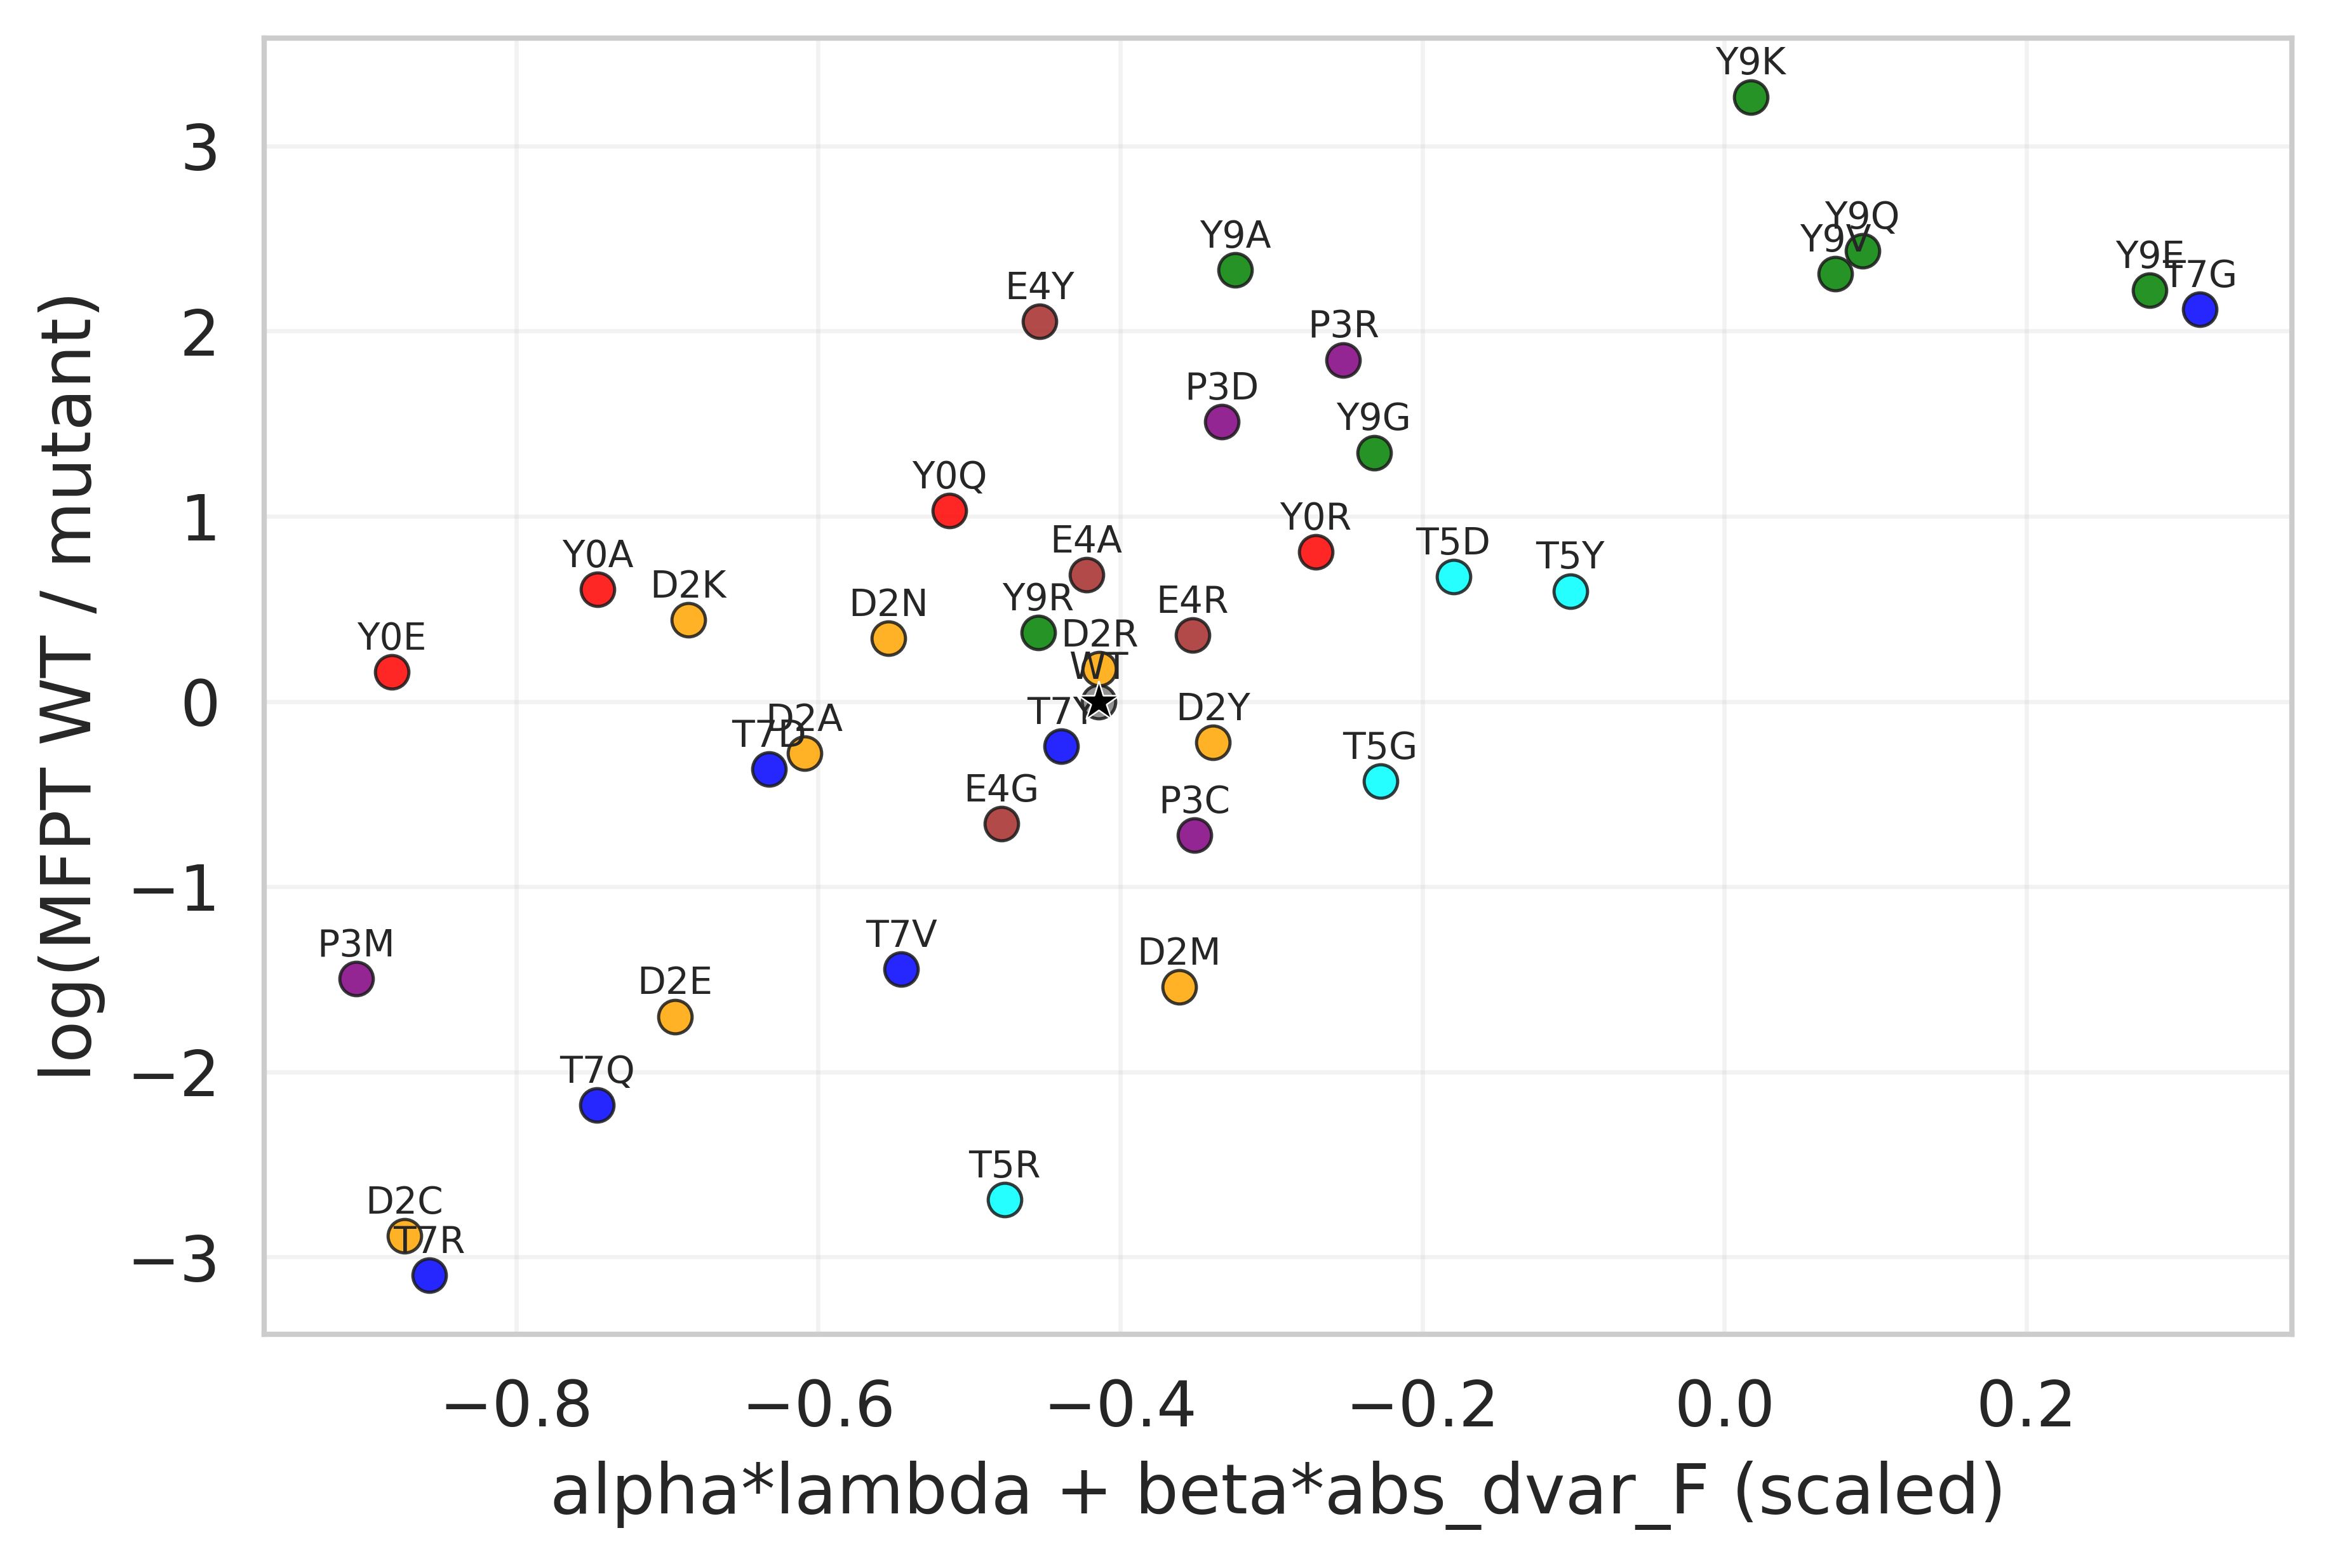

In [8]:
# Combine lambda + abs_dvar_F with weighted sum (optimize alpha, beta)
sub = summary_df.dropna(subset=['lambda', 'abs_dvar_F', 'log_mfpt_ratio']).copy()

lmin, lmax = sub['lambda'].min(), sub['lambda'].max()
amin, amax = sub['abs_dvar_F'].min(), sub['abs_dvar_F'].max()
sub['lambda_z'] = (sub['lambda'] - lmin) / (lmax - lmin) if lmax > lmin else 0.0
sub['abs_dvar_F_z'] = (sub['abs_dvar_F'] - amin) / (amax - amin) if amax > amin else 0.0

best = None
for alpha in np.linspace(-1.0, 1.0, 81):
    for beta in np.linspace(-1.0, 1.0, 81):
        comb = alpha * sub['lambda_z'] + beta * sub['abs_dvar_F_z']
        rho = comb.corr(sub['log_mfpt_ratio'], method='spearman')
        val = abs(rho) if pd.notna(rho) else np.nan
        if pd.isna(val):
            continue
        if best is None or val > best['rho_abs']:
            best = {'alpha': float(alpha), 'beta': float(beta), 'rho_abs': float(val), 'rho': float(rho)}

print(f"Best combo: alpha={best['alpha']:.2f}, beta={best['beta']:.2f}, ρ={best['rho']:.2f}")
sub['combo'] = best['alpha'] * sub['lambda_z'] + best['beta'] * sub['abs_dvar_F_z']

fig, ax = plt.subplots(figsize=(6.2, 4.2))
palette = {int(k): v for k, v in res_colors.items() if k in sub['residue_idx'].unique()}
scatter_with_labels(
    ax,
    sub,
    'combo',
    'log_mfpt_ratio',
    label_col=None,
    color_col='residue_idx',
    colors=palette,
    s=40,
    edgecolor='k',
    linewidth=0.6,
    alpha=0.85,
    annotate=True,
)
wt_row = sub.loc[sub.index == 'WT']
wt_x = float(wt_row.iloc[0]['combo'])
wt_y = float(wt_row.iloc[0]['log_mfpt_ratio'])
ax.plot(
    wt_x,
    wt_y,
    marker='*',
    markersize=8,
    color='black',
    markeredgecolor='white',
    markeredgewidth=0.3,
    zorder=5,
)
ax.set_xlabel('alpha*lambda + beta*abs_dvar_F (scaled)')
ax.set_ylabel('log(MFPT WT / mutant)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [9]:
print(list(lambda_grid['tF']))
print(list(lambda_grid['tU']))

[0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.32, 0.32, 0.32, 0.32, 0.32, 0.32, 0.32, 0.32, 0.32, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.39, 0.39, 0.39, 0.39, 0.39, 0.39, 0.39, 0.39, 0.43, 0.43, 0.43, 0.43, 0.43, 0.43, 0.43, 0.46, 0.46, 0.46, 0.46, 0.46, 0.46, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.18, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.29, 0.32, 0.32, 0.32, 0.32, 0.32, 0.32, 0.32, 0.32, 0.32, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.39, 0.39, 0.39, 0.39, 0.39, 0.39, 0.39, 0.39, 0.43, 0.43, 0.43, 0.43, 0.43, 0.43, 0.43, 0.46, 0.46, 0.46, 0.46, 0.46, 0.46, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.1

[695.08, 258.46, 202.87, 360.31, 499.91, 494.36, 311.93, 48.84, 216.49, 924.79]


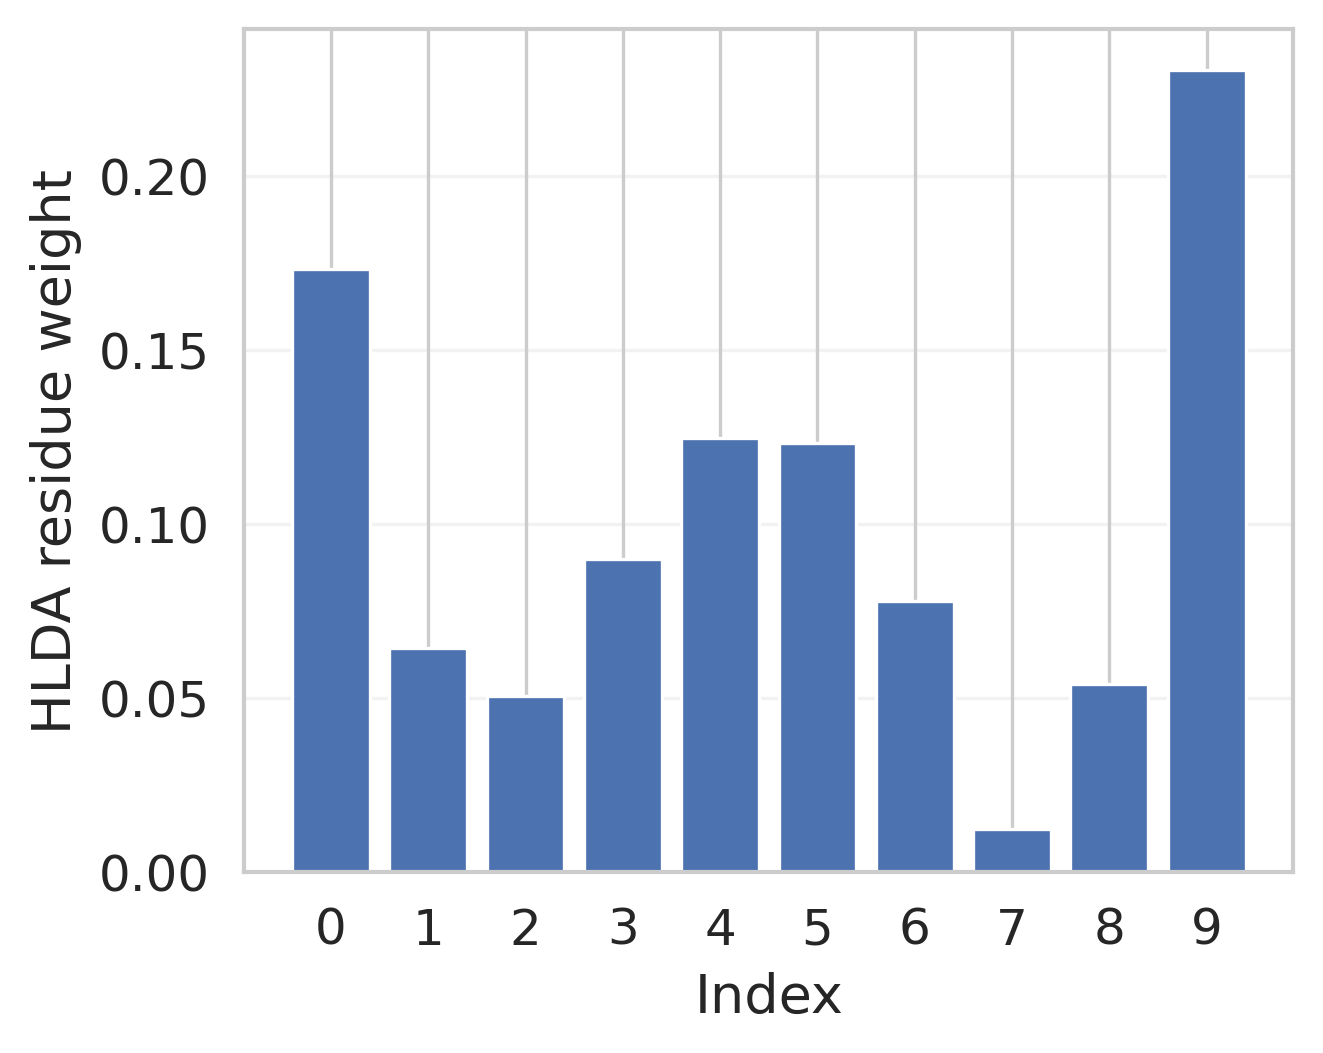

In [10]:
tF = 0.25
tU = 0.63

wt_row = lambda_grid[(lambda_grid['Mutant'] == 'WT') & (lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
res_weights = wt_row.iloc[0]['res_weights']

print(res_weights)
fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi=150)
ax.bar(list(range(len(res_weights))), res_weights / np.sum(res_weights), color='#4C72B0')
ax.set_xlabel('Index')
ax.set_ylabel('HLDA residue weight')
ax.set_xticks(list(range(0, 10)))
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


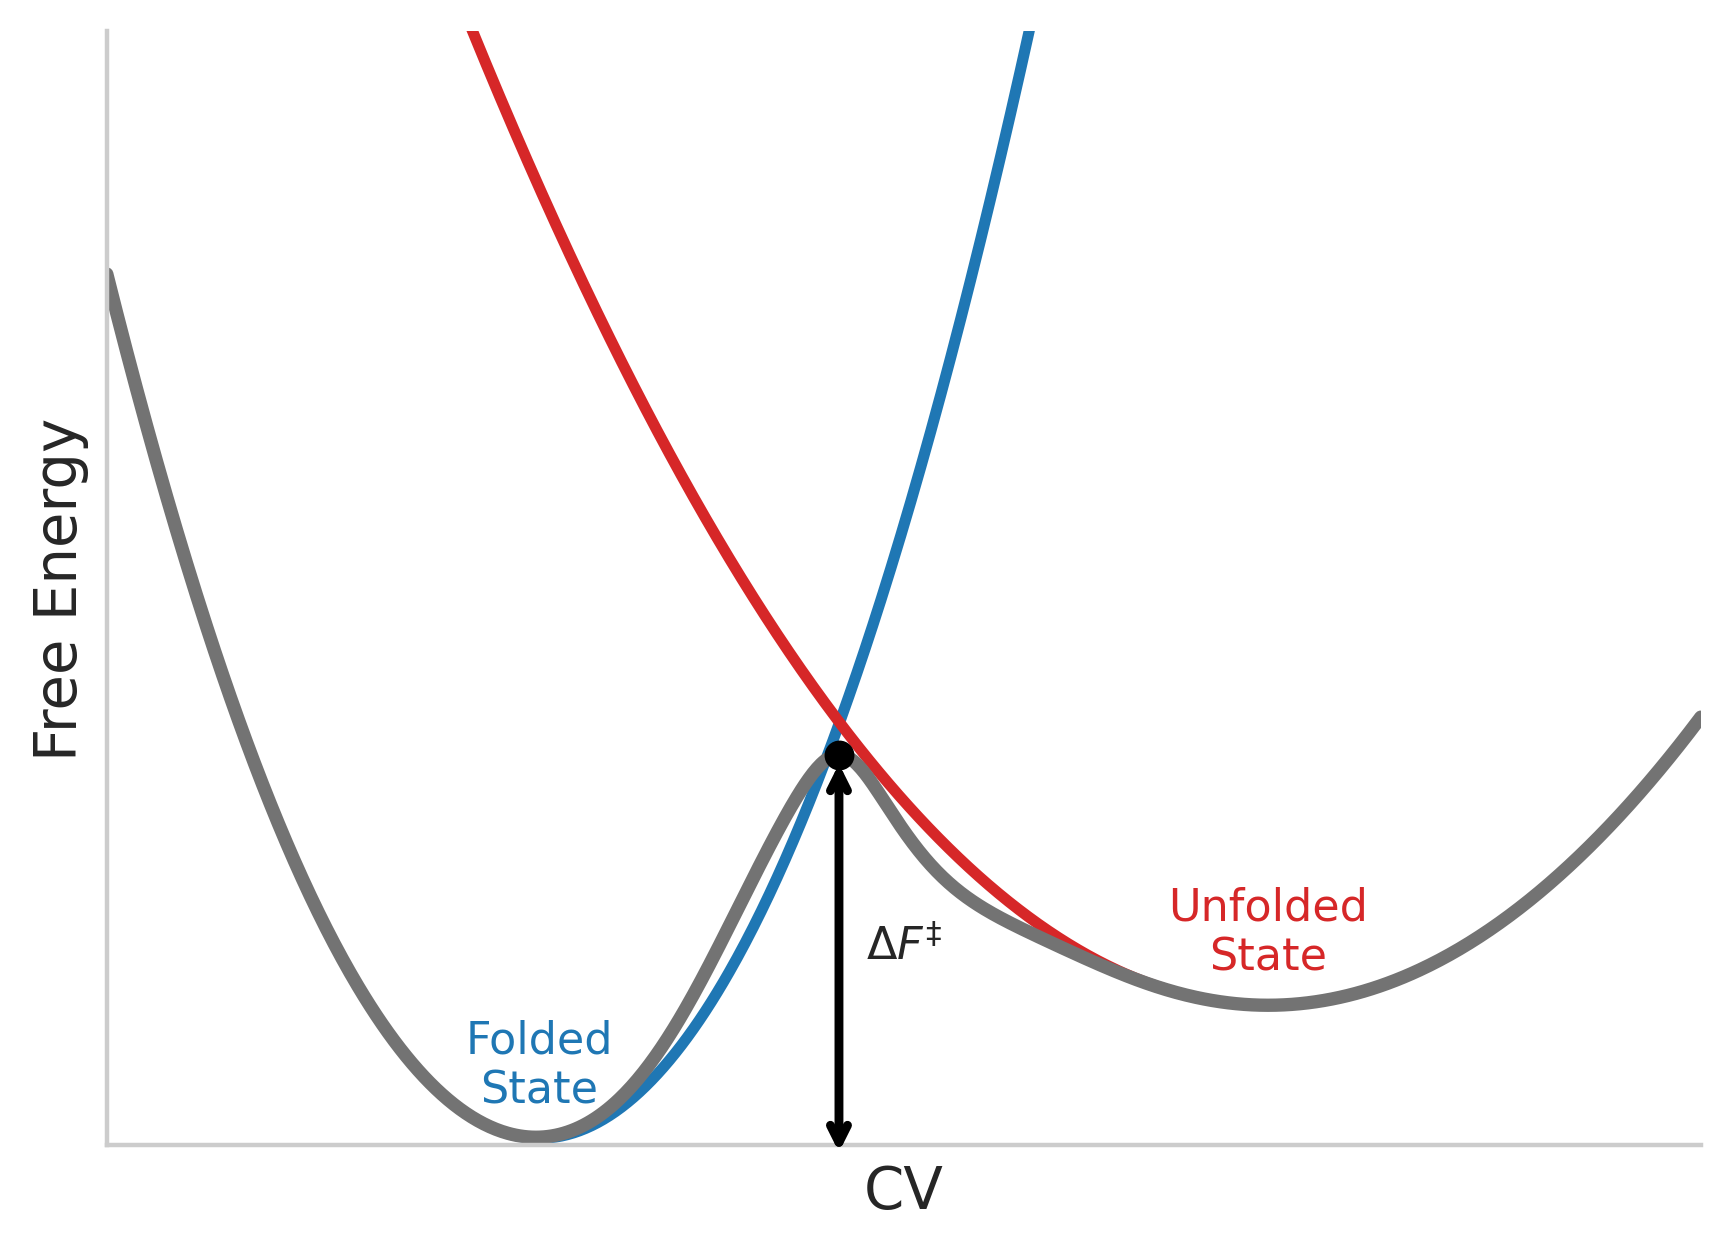

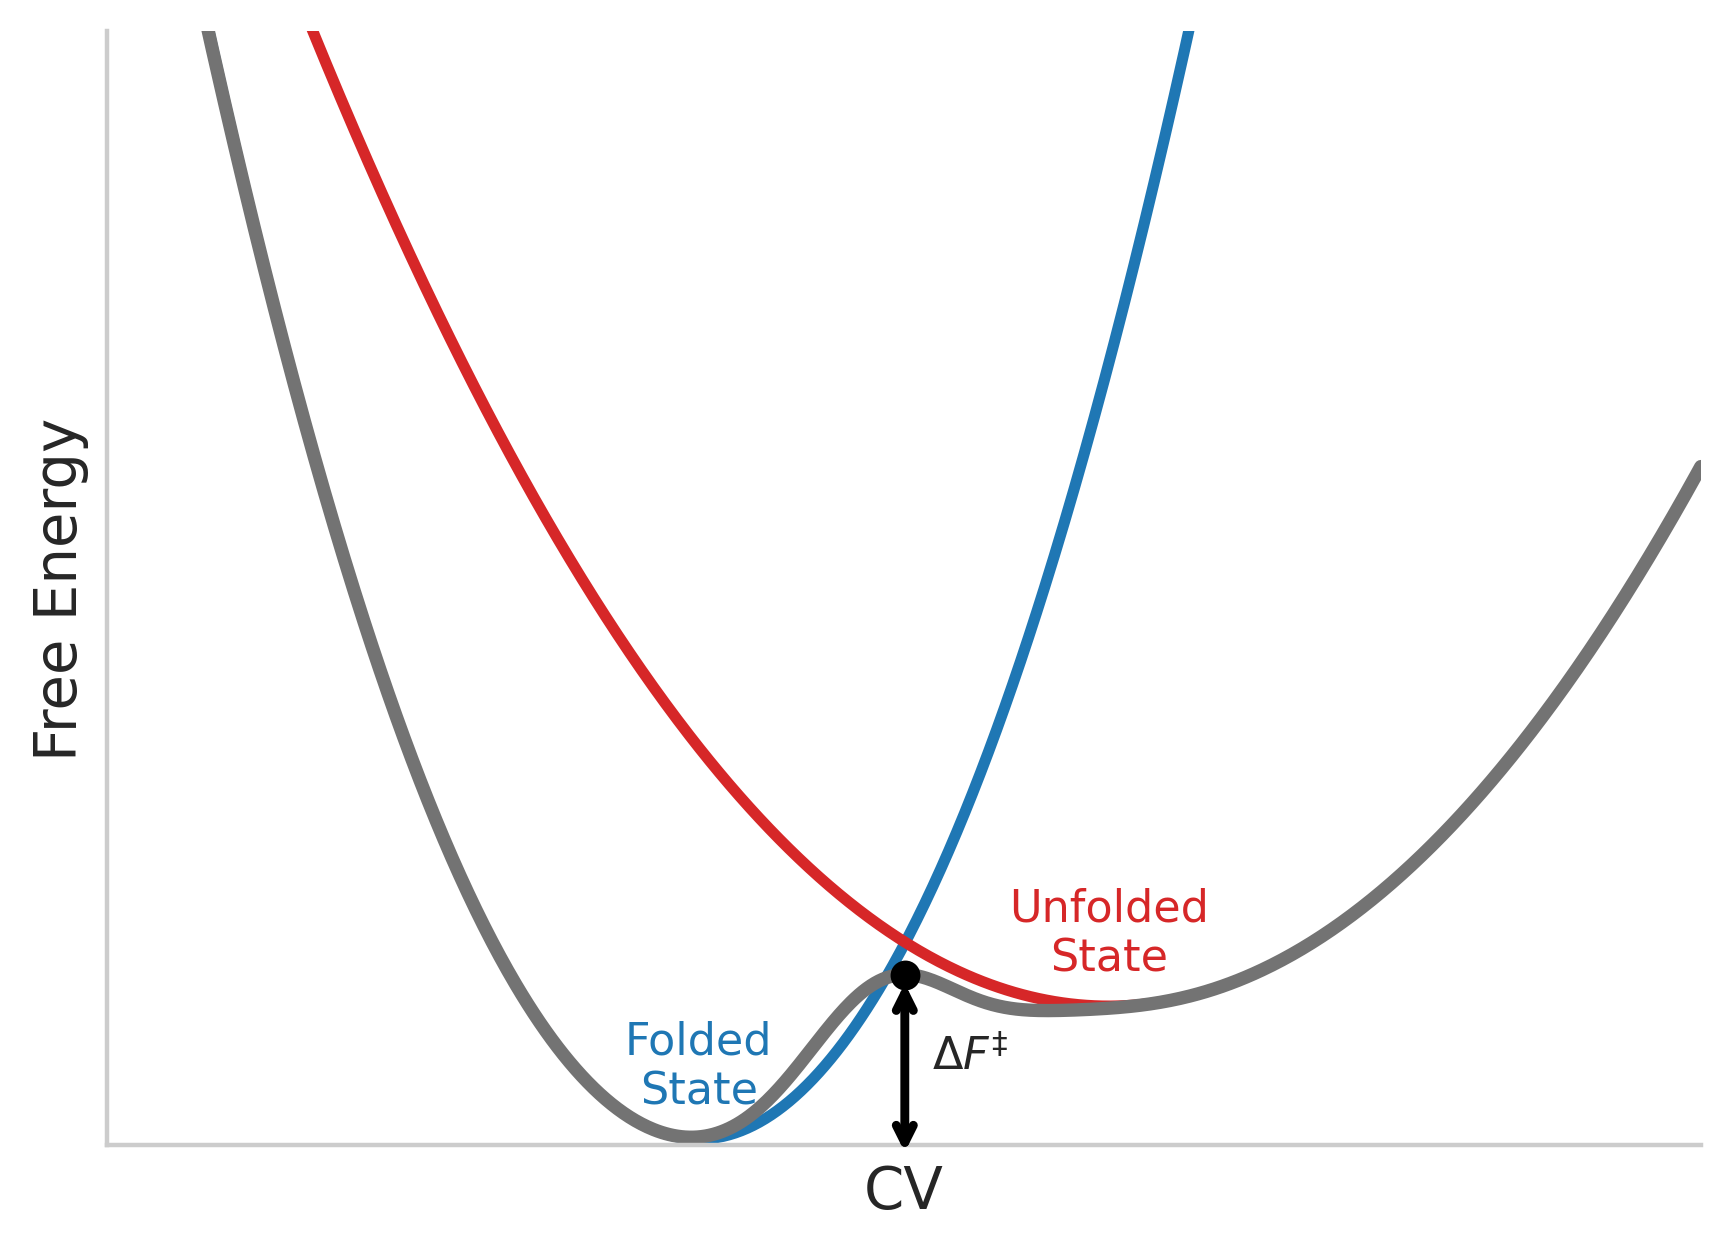

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def well(x, x0=0.0, k=1.0, offset=0.0):
    return 0.5 * k * (x - x0) ** 2 + offset

def fes_mix_logsumexp(F1, F2, beta=3.0):
    m = np.minimum(F1, F2)
    return m - (1.0 / beta) * np.log(np.exp(-beta * (F1 - m)) + np.exp(-beta * (F2 - m)))

def style_axis(ax):
    ax.set_xlabel("CV")
    ax.set_ylabel("Free Energy")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

def intersection_index(x, F1, F2):
    return int(np.argmin(np.abs(F1 - F2)))

def fes_peak_at_intersection(x, F1, F2, beta=3.0, sigma=0.35, delta_under=0.12):
    """
    Smooth gray curve that:
      - is based on the smooth lower envelope (soft-min) => "physical" lowering
      - has a local maximum exactly at x* where F1=F2 (intersection in x)
      - peak y is BELOW the intersection energy by delta_under (illustration control)
    """
    F_base = fes_mix_logsumexp(F1, F2, beta=beta)

    i_star = intersection_index(x, F1, F2)
    x_star = x[i_star]
    E_int  = 0.5 * (F1[i_star] + F2[i_star])  # ~ intersection energy

    g = np.exp(-0.5 * ((x - x_star) / sigma) ** 2)

    # cancel the slope of the baseline at x* so the peak sits exactly at x*
    dFdx = np.gradient(F_base, x)
    B = -dFdx[i_star]  # makes derivative at x* zero

    # set the peak height at x* to be below intersection energy
    target_peak = E_int - delta_under
    A = target_peak - F_base[i_star]  # bump amplitude (since skew term is 0 at x*)

    F = F_base + A * g + B * (x - x_star) * g

    # if it somehow isn't a *maximum* at x*, nudge A up slightly (rare)
    # (keeps it smooth and still centered at x*)
    for _ in range(3):
        d2 = np.gradient(np.gradient(F, x), x)
        if d2[i_star] < 0:
            break
        A += 0.05
        F = F_base + A * g + B * (x - x_star) * g

    return F, i_star

def add_barrier_height_arrow_at_index(ax, x, Fmix, i_top,
                                      label=r"$\Delta F^{\ddagger}$"):
    xb = x[i_top]
    yb = Fmix[i_top]
    y0 = np.min(Fmix)

    ax.annotate(
        "",
        xy=(xb, yb),
        xytext=(xb, y0 - 0.09),
        arrowprops=dict(arrowstyle="<->", lw=2.0, color="black"),
        zorder=6,
    )
    ax.scatter([xb], [yb], s=35, color="black", zorder=7)
    ax.text(xb + 0.12, 0.5 * (y0 + yb), label, va="center", fontsize=10)

# ---------- x-grid ----------
x = np.linspace(-3.5, 3.5, 800)

# Shared basin shapes (same for WT and mutant)
kF = 1.8
kU = 0.6
oF = 0.0
oU = 0.5

# illustration knobs (tune)
delta_under = 0.12   # peak sits this much BELOW the blue/red intersection (y-axis)
sigma_wt    = 0.40
sigma_mut   = 0.32

# ---------- PANEL A: Wildtype ----------
wt = dict(xF=-1.6, xU=+1.6, beta=4.2)
F_fold_wt = well(x, wt["xF"], kF, oF)
F_unf_wt  = well(x, wt["xU"], kU, oU)
F_mix_wt, i_peak_wt = fes_peak_at_intersection(
    x, F_fold_wt, F_unf_wt, beta=wt["beta"], sigma=sigma_wt, delta_under=delta_under
)

# ---------- PANEL B: Point mutant ----------
mut = dict(xF=-0.9, xU=+0.9, beta=3.2)
F_fold_mut = well(x, mut["xF"], kF, oF)
F_unf_mut  = well(x, mut["xU"], kU, oU)
F_mix_mut, i_peak_mut = fes_peak_at_intersection(
    x, F_fold_mut, F_unf_mut, beta=mut["beta"], sigma=sigma_mut, delta_under=delta_under
)

# ---------- shift each panel so its minimum is at ~0 ----------
shift_wt = np.min(F_mix_wt) - 0.03
F_fold_wt -= shift_wt
F_unf_wt  -= shift_wt
F_mix_wt  -= shift_wt

shift_mut = np.min(F_mix_mut) - 0.03
F_fold_mut -= shift_mut
F_unf_mut  -= shift_mut
F_mix_mut  -= shift_mut

# ---------- plot ----------
# ---------- plot (WT) ----------
# ---------- plot (WT) ----------
fig_wt, ax_wt = plt.subplots(1, 1, figsize=(6, 4), dpi=200)
ax_wt.plot(x, F_fold_wt, lw=2.5, color="#1f77b4")
ax_wt.plot(x, F_unf_wt,  lw=2.5, color="#d62728")
ax_wt.plot(x, F_mix_wt,  lw=3.0, color="0.45")
style_axis(ax_wt)
ax_wt.text(wt["xF"], np.min(F_fold_wt)+0.10, "Folded\nState", color="#1f77b4",
           ha="center", va="bottom", fontsize=10)
ax_wt.text(wt["xU"], np.min(F_unf_wt)+0.10, "Unfolded\nState", color="#d62728",
           ha="center", va="bottom", fontsize=10)
add_barrier_height_arrow_at_index(ax_wt, x, F_mix_wt, i_peak_wt)

# ---------- plot (Mutant) ----------
fig_mut, ax_mut = plt.subplots(1, 1, figsize=(6, 4), dpi=200)
ax_mut.plot(x, F_fold_mut, lw=2.5, color="#1f77b4")
ax_mut.plot(x, F_unf_mut,  lw=2.5, color="#d62728")
ax_mut.plot(x, F_mix_mut,  lw=3.0, color="0.45")
style_axis(ax_mut)
ax_mut.text(mut["xF"], np.min(F_fold_mut)+0.10, "Folded\nState", color="#1f77b4",
            ha="center", va="bottom", fontsize=10)
ax_mut.text(mut["xU"], np.min(F_unf_mut)+0.10, "Unfolded\nState", color="#d62728",
            ha="center", va="bottom", fontsize=10)
add_barrier_height_arrow_at_index(ax_mut, x, F_mix_mut, i_peak_mut)

# limits (identical)
ymax = max(F_mix_wt.max(), F_mix_mut.max()) * 0.70
for ax in (ax_wt, ax_mut):
    ax.set_ylim(0.0, ymax)
    ax.set_xlim(x.min(), x.max())

fig_wt.tight_layout()
fig_mut.tight_layout()
plt.show()
